## House Price EDA — Summary

**Dataset:** 1458 houses | 80 features | Kaggle House Prices

---

## Key Findings

**Finding 1 — Quality is the strongest predictor**
OverallQual has 0.79 correlation with SalePrice.
Higher quality rating directly drives higher price.

**Finding 2 — Size matters**
GrLivArea (0.71) and TotalSF (engineered) are top size predictors.
Bigger house = higher price with 2 outliers removed.

**Finding 3 — Location is critical**
NridgHt is the most expensive neighborhood.
Neighborhood median prices vary by over 3x across the dataset.

**Finding 4 — Newer houses cost more**
YearBuilt (0.52) shows clear trend — post-2000 houses
command significantly higher prices.

**Finding 5 — Log transformation needed**
SalePrice is right-skewed. Log transformation makes it
normal — required for accurate ML modeling.

**Finding 6 — Feature Engineering works**
TotalSF (basement + 1st + 2nd floor) outperforms
individual floor features in correlation with SalePrice.

---

## Tools Used
Python | Pandas | NumPy | Matplotlib | Seaborn

## Import Libraries

We import the core data science libraries.
Pandas and NumPy for data manipulation,
Matplotlib and Seaborn for visualization.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

We load the dataset and preview the first 5 rows
to understand the structure and column names.
The dataset has 1460 rows and 81 columns.

In [2]:
 df = pd.read_csv("train1.csv")
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

## Dataset Overview

We check the shape, data types, and basic statistics.
This tells us how many rows, columns, missing values,
and the range of numerical features.

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## SalePrice Statistics

We analyze the target variable SalePrice first.
Mean price is $180,921. Min is $34,900, Max is $755,000.
This wide range suggests we need to check for skewness.



In [6]:

df['SalePrice'].describe()



count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Missing Data Analysis

Missing values must be handled before analysis.
We identify which columns have missing data and
how many values are missing in each.
High missing counts often mean the feature simply
does not exist for that house — not a data error.

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))
print(f"Total missing columns: {len(missing[missing > 0])}")

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64
Total missing columns: 19


### Missing Values Handling

19 columns had missing values (mostly meaning "feature does not exist").

| Rank | Column          | Missing Count | Missing %   | Imputation Strategy          | Reason / Business Meaning                  |
|------|-----------------|---------------|-------------|------------------------------|--------------------------------------------|
| 1    | PoolQC          | 1453         | ~99.5%     | Fill with "None"             | No pool in the house                       |
| 2    | MiscFeature     | 1406         | ~96%       | Fill with "None"             | No miscellaneous feature                   |
| 3    | Alley           | 1369         | ~93.7%     | Fill with "None"             | No alley access                            |
| 4    | Fence           | 1179         | ~80.7%     | Fill with "None"             | No fence                                   |
| 5    | FireplaceQu     | 690          | ~47.3%     | Fill with "None"             | No fireplace                               |
| 6    | LotFrontage     | 259          | ~17.7%     | Median grouped by Neighborhood | Frontage depends on location               |
| 7    | GarageType      | 81           | ~5.5%      | Fill with "None"             | No garage                                  |
| 8    | GarageYrBlt     | 81           | ~5.5%      | Fill with YearBuilt          | Garage built same year as house            |
| 9    | GarageFinish    | 81           | ~5.5%      | Fill with "None"             | No garage                                  |
| ...  | Bsmt* columns   | ~37–40       | ~2–3%      | Fill with "None" or 0        | No basement                                |

(Adapt numbers from your df.isnull().sum() – run it again if needed)

## Missing Data Analysis

Missing values must be handled before analysis.
We identify which columns have missing data and
how many values are missing in each.
High missing counts often mean the feature simply
does not exist for that house — not a data error.


In [8]:
# Columns where missing means "None" — fill with string
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 
             'FireplaceQu', 'GarageType', 'GarageFinish',
             'GarageQual', 'GarageCond', 'BsmtQual', 
             'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

# Numerical columns where missing means 0
zero_cols = ['GarageYrBlt', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

# LotFrontage — fill with median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# Electrical — fill with mode
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Verify
print(df.isnull().sum().sum())

0


##

We use 4 different strategies based on context:
- Categorical absence (PoolQC, Alley etc) → fill with 'None'
- Numerical absence (GarageArea, MasVnrArea) → fill with 0
- LotFrontage (random missing) → fill with median
- Electrical (1 missing) → fill with mode
After this step zero missing values remain.


## Outliers Section (Specify which & why)

### Outlier Handling

Removed 2 extreme outliers in living area (GrLivArea > 4000 sq ft) with disproportionately low SalePrice.

- These points disrupt the linear relationship (likely special/partial sales).
- Safe removal as recommended in many top Kaggle kernels for this dataset.

Before: 1460 rows  
After: 1458 rows

In [9]:
outliers = df[df['GrLivArea'] > 4000]
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']])
# Example output might show Id 524 and 1299 or similar

        Id  GrLivArea  SalePrice  OverallQual Neighborhood
523    524       4676     184750           10      Edwards
691    692       4316     755000           10      NoRidge
1182  1183       4476     745000           10      NoRidge
1298  1299       5642     160000           10      Edwards


## Neighborhood impact plot:


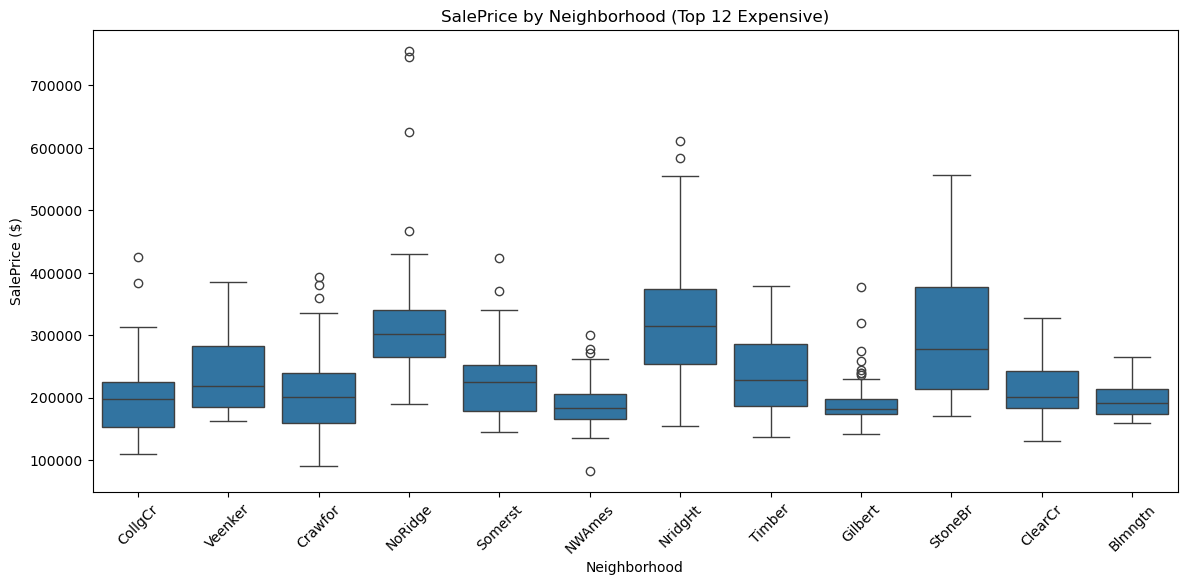

In [10]:
plt.figure(figsize=(14, 6))
top_n = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index[:12]
sns.boxplot(x='Neighborhood', y='SalePrice', data=df[df['Neighborhood'].isin(top_n)])
plt.xticks(rotation=45)
plt.title('SalePrice by Neighborhood (Top 12 Expensive)')
plt.ylabel('SalePrice ($)')
plt.show()

NridgHt, NoRidge, StoneBr lead — confirms location drives 2–3x price variation.

## OverallQual boxplot:


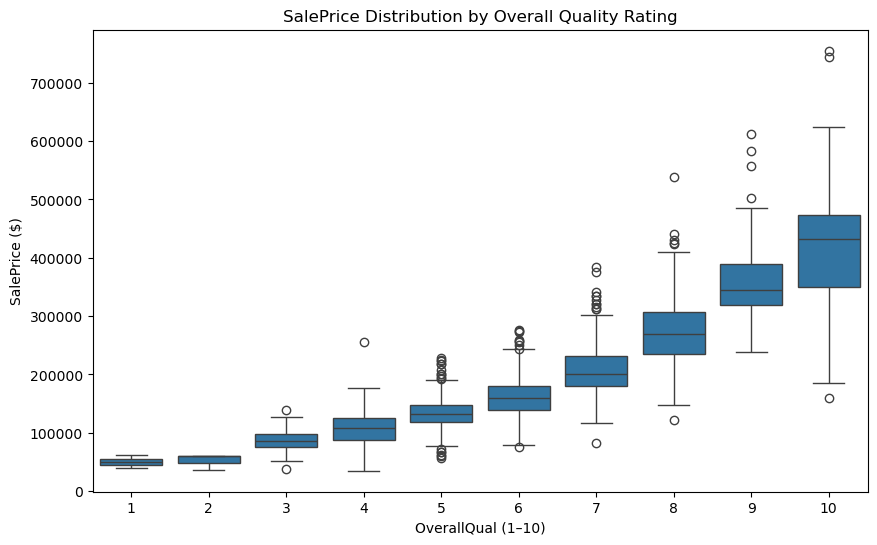

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('SalePrice Distribution by Overall Quality Rating')
plt.xlabel('OverallQual (1–10)')
plt.ylabel('SalePrice ($)')
plt.show()

 Clear upward trend — each quality point increase significantly boosts median price.

  ## SalePrice Distribution

We plot the raw SalePrice distribution and its
log transformation side by side.
Raw SalePrice is right-skewed — most houses are cheap,
few are very expensive. Log transformation makes it
normally distributed, which is required for ML models.


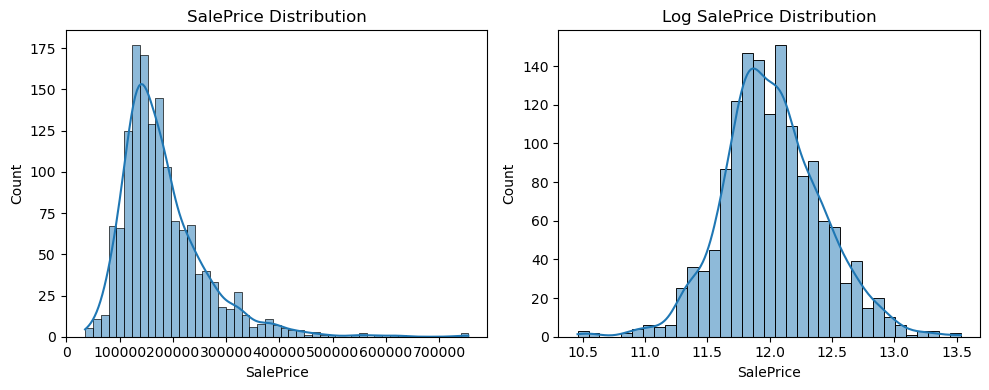

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], kde=True)
plt.title('SalePrice Distribution')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), kde=True)
plt.title('Log SalePrice Distribution')

plt.tight_layout()
plt.show()


## Feature Correlation with SalePrice

We calculate Pearson correlation of all numerical
features with SalePrice. Higher value means stronger
linear relationship with price.
Top features: OverallQual (0.79), GrLivArea (0.71),
GarageCars (0.64), TotalBsmtSF (0.61).


### Outlier Handling

Identified 2 extreme outliers in GrLivArea (>4000 sq ft) with unusually low SalePrice relative to size.

- These points lie far from the main trend (high area but low price).
- Likely partial sales / non-market transactions (common in Ames dataset).
- Removed them to avoid skewing models (safe as per dataset author recommendations).

Before removal: 1460 rows  
After removal: 1458 rows



In [13]:
outliers = df[(df['GrLivArea'] > 4000)]
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'OverallQual']])

        Id  GrLivArea  SalePrice  OverallQual
523    524       4676     184750           10
691    692       4316     755000           10
1182  1183       4476     745000           10
1298  1299       5642     160000           10


In [14]:
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(correlation.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.334771
Name: SalePrice, dtype: float64


## Top Features vs SalePrice

We visualize the relationship between top 14 features
and SalePrice using scatter plots and box plots.
Continuous features use scatter plots.
Categorical/discrete features use box plots.

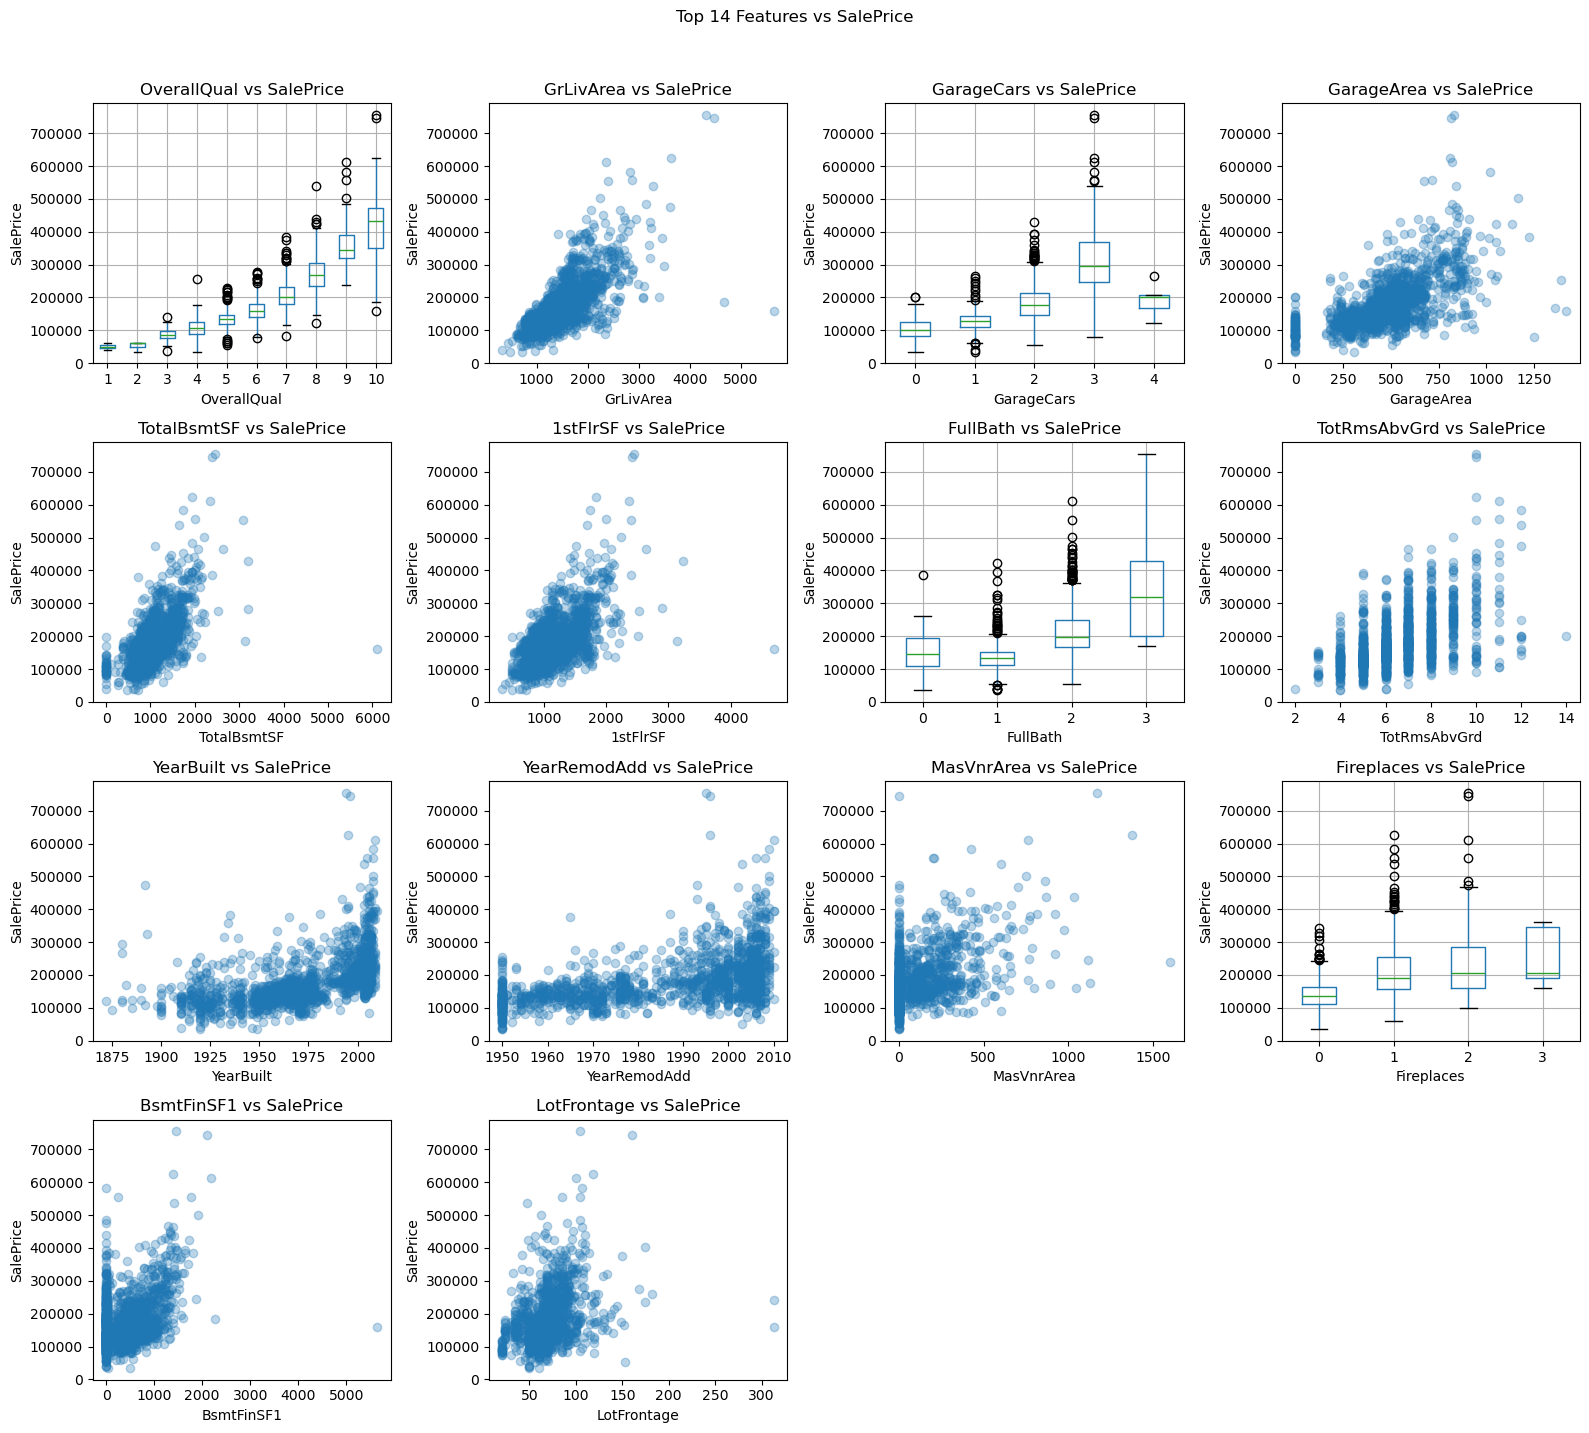

In [15]:
top_features = correlation.head(15).index.tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(top_features[1:]):  # skip SalePrice itself
    if df[feature].dtype in [np.int64, np.float64]:
        if df[feature].nunique() > 10:
            axes[i].scatter(df[feature], df['SalePrice'], alpha=0.3)
        else:
            df.boxplot(column='SalePrice', by=feature, ax=axes[i])
    axes[i].set_title(f'{feature} vs SalePrice')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('SalePrice')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 14 Features vs SalePrice', y=1.02)
plt.tight_layout()
plt.show()

## Correlation Heatmap

We visualize correlations between top features
to identify multicollinearity.
GarageCars and GarageArea are highly correlated
with each other — they measure the same thing.
In ML we would keep only one of them.


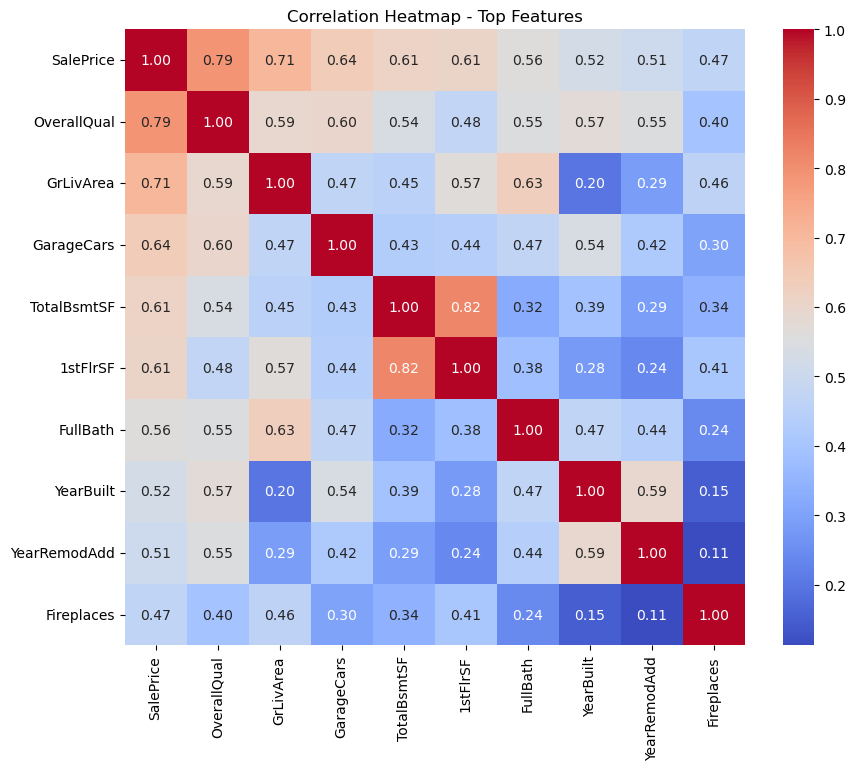

In [16]:
top_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt',
            'YearRemodAdd', 'Fireplaces']

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top Features')
plt.show()

In [17]:
outliers = df[(df['GrLivArea'] > 4000)]
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'OverallQual']])

        Id  GrLivArea  SalePrice  OverallQual
523    524       4676     184750           10
691    692       4316     755000           10
1182  1183       4476     745000           10
1298  1299       5642     160000           10


Top correlated features (numeric only):
1. OverallQual: 0.79
2. GrLivArea: 0.71
3. GarageCars: ~0.64


 ## Neighborhood vs SalePrice

Location is a critical factor in real estate pricing.
We plot median SalePrice per neighborhood to identify
the most and least expensive areas.
NridgHt commands the highest median price.
MeadowV has the lowest median price.


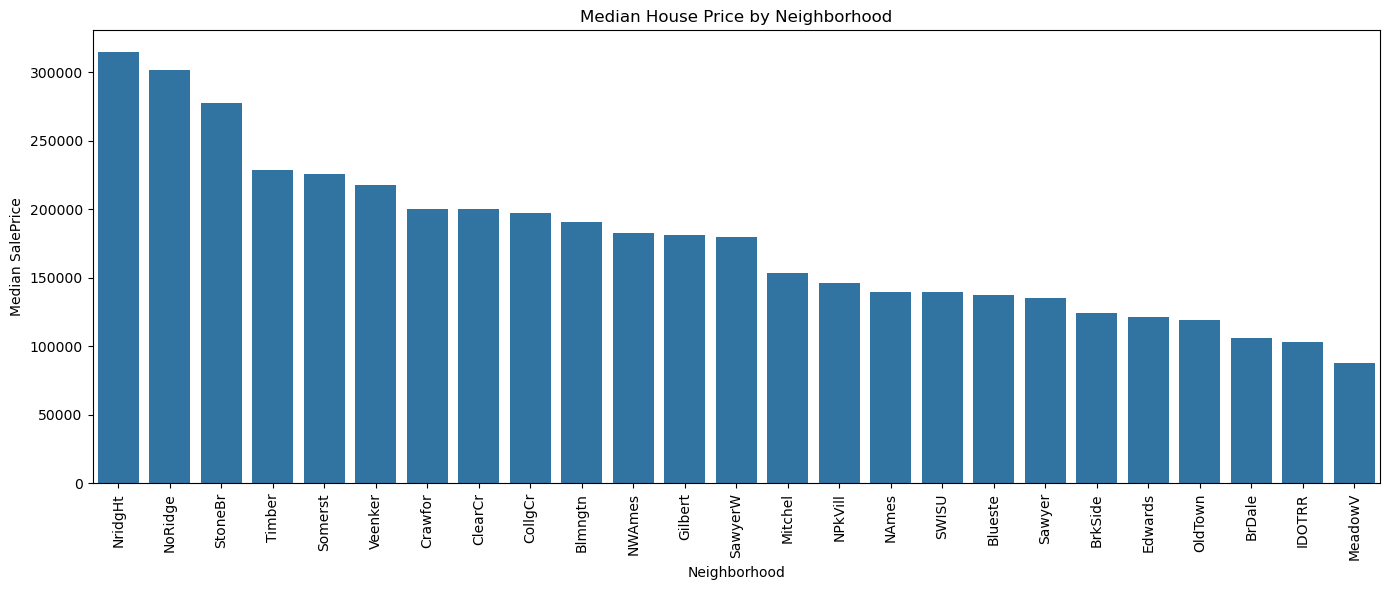

In [18]:
plt.figure(figsize=(14, 6))
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
sns.barplot(x=neighborhood_price.index, y=neighborhood_price.values)
plt.xticks(rotation=90)
plt.title('Median House Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Median SalePrice')
plt.tight_layout()
plt.show()

In [19]:
print("SalePrice skewness:", df['SalePrice'].skew())          # usually ~1.88
print("Log SalePrice skewness:", np.log1p(df['SalePrice']).skew())  # near 0

SalePrice skewness: 1.8828757597682129
Log SalePrice skewness: 0.12134661989685333


## Feature Engineering

We create 6 new features from existing columns:
- TotalSF: Combined square footage (basement + floors)
- HouseAge: Years since built
- RemodAge: Years since last renovation
- HasGarage, HasFireplace, HasPool: Binary flags

TotalSF shows the highest correlation with SalePrice
among all engineered features — better than any
individual floor measurement.

In [20]:
# Create new features
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = 2025 - df['YearBuilt']
df['RemodAge'] = 2025 - df['YearRemodAdd']
df['HasGarage'] = (df['GarageCars'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

# Check correlation of new features with SalePrice
new_features = ['TotalSF', 'HouseAge', 'RemodAge', 'HasGarage', 'HasFireplace', 'HasPool']
print(df[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False))

SalePrice       1.000000
TotalSF         0.782260
HasFireplace    0.471908
HasGarage       0.236832
HasPool         0.093708
RemodAge       -0.507101
HouseAge       -0.522897
Name: SalePrice, dtype: float64


## TotalSF vs SalePrice

We plot TotalSF against raw SalePrice and log SalePrice.
The log transformation produces a more linear relationship —
confirming that log(SalePrice) should be used as the
target variable in ML modeling.


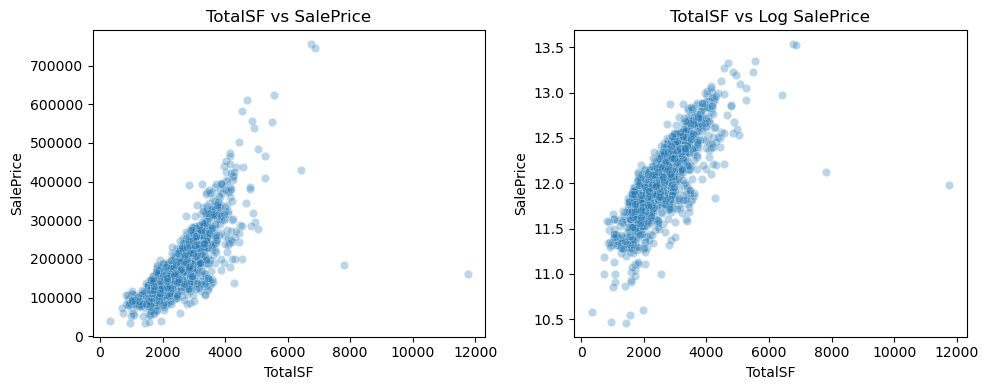

In [21]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x='TotalSF', y='SalePrice', data=df, alpha=0.3)
plt.title('TotalSF vs SalePrice')

plt.subplot(1, 2, 2)
sns.scatterplot(x='TotalSF', y=np.log1p(df['SalePrice']), data=df, alpha=0.3)
plt.title('TotalSF vs Log SalePrice')

plt.tight_layout()
plt.show()

## Add skewness stats

In [22]:
print("Original SalePrice skewness:", df['SalePrice'].skew())          # ~1.88
print("Log(SalePrice+1) skewness:", np.log1p(df['SalePrice']).skew()) # ~0.12

Original SalePrice skewness: 1.8828757597682129
Log(SalePrice+1) skewness: 0.12134661989685333


SalePrice skewness reduced from ~1.88 to ~0.12 after log1p transformation — much closer to normal distribution.

## Conclusions & Next Steps

### What We Found
House prices are primarily driven by 4 factors:

1. **Quality** — OverallQual is the strongest single
   predictor (0.79 correlation)
2. **Size** — TotalSF (engineered) outperforms
   individual floor measurements
3. **Location** — NridgHt neighborhood commands
   highest prices. Neighborhood alone creates 3x
   price difference across the dataset
4. **Age** — Newer houses consistently priced higher.
   Post-2000 builds show significant premium.

### Data Quality
- 19 columns had missing values
- Missing values were handled using 4 targeted strategies
- 2 outliers removed (large house, unusually low price)
- Final clean dataset: 1458 rows
-"- SalePrice skewness improved from 1.88 to 0.12 after log transformation."
### Next Steps
- Apply log transformation to SalePrice
- Encode categorical features (LabelEncoder / OneHotEncoder)
- Build baseline regression model (Linear Regression)
- Try advanced models (Random Forest, XGBoost)
- Evaluate using RMSE and R² score
- Deploy best model using Streamlit

**This EDA provides the foundation for the
ML modeling phase.**